In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from templates import *
from templates_cls import *
from experiment_classifier import ClsModel

In [3]:
device = 'cuda:0'
conf = ffhq256_autoenc()
# print(conf.name)

model = LitModel(conf)
state = torch.load(f'checkpoints/{conf.name}/last.ckpt', map_location='cpu')
model.load_state_dict(state['state_dict'], strict=False)
model.ema_model.eval()
model.ema_model.to(device);

Seed set to 0


Model params: 160.69 M


In [ ]:
conf.name

'ffhq256_autoenc'

In [5]:
# # device = 'cuda:0'
# conf2 = ffhq256_autoenc_mlp()
# print(conf2.name)

# model_z = conf2.make_model_conf().make_model()
# ema_model_z = copy.deepcopy(model_z)
# model_z.requires_grad_(False)
# ema_model_z.requires_grad_(False)
# ema_model_z.eval()


# state = torch.load(conf2.pretrain.path, map_location='cpu')
# model_z.load_state_dict(state['state_dict'], strict=False)
# ema_model_z.load_state_dict(state['state_dict'], strict=False)

# model_z.to(device)
# ema_model_z.to(device)

In [6]:
from templates_cls import ffhq256_autoenc_cls
from experiment_classifier import ClsModel
cls_conf = ffhq256_autoenc_cls()
cls_model = ClsModel(cls_conf)
state = torch.load(f'checkpoints/{cls_conf.name}/last.ckpt',
                    map_location='cpu')
print('latent step:', state['global_step'])
cls_model.load_state_dict(state['state_dict'], strict=False);
cls_model.to(device);

Seed set to 0


loading pretrain ... 130M
step: 1563562
loading latent stats ...
latent step: 9375


In [7]:
# data = conf.make_dataset()
# batch = data[10]['img'][None]

In [8]:
# data = ImageDataset('imgs_align', image_size=conf.img_size, exts=['jpg', 'JPG', 'png'], do_augment=False)
# batch = data[0]['img'][None]

In [9]:
from torch.utils.data import DataLoader

dataset_glass = FFHQlmdb_mlp(path='datasets/ffhq256_mlp/ffhq256_glass.lmdb', image_size=256)
dataset_bg = FFHQlmdb_mlp(path='datasets/ffhq256_mlp/ffhq256_bg.lmdb', image_size=256)

dataloader_glass = DataLoader(dataset_glass, batch_size=1, shuffle=True, num_workers=4)
dataloader_bg = DataLoader(dataset_bg, batch_size=1, shuffle=True, num_workers=4)

for batches_glass in dataloader_glass:
    batch_glass = batches_glass['img']  # Extract image tensors
    print(batch_glass.shape)  # Example: torch.Size([32, 3, 256, 256])
    break  # Test one batch

for batches_bg in dataloader_bg:
    batch_bg = batches_bg['img']  # Extract image tensors
    print(batch_bg.shape)  # Example: torch.Size([32, 3, 256, 256])
    break  # Test one batch

# ori_glass = (batch_glass + 1) / 2
# ori_bg = (batch_bg + 1) / 2

torch.Size([1, 3, 256, 256])
torch.Size([1, 3, 256, 256])


In [10]:
cond_glass = model.encode(batch_glass.to(device))
xT_glass = model.encode_stochastic(batch_glass.to(device), cond_glass, T=250)

cond_bg = model.encode(batch_bg.to(device))
xT_bg = model.encode_stochastic(batch_bg.to(device), cond_bg, T=250)

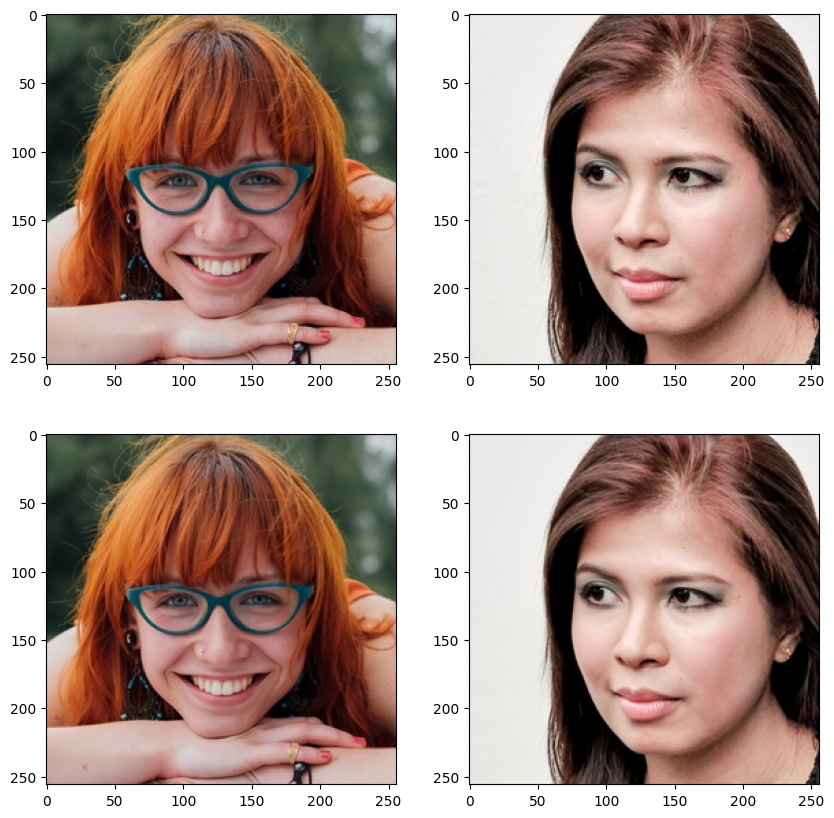

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

ori_glass = (batch_glass + 1) / 2
ori_bg = (batch_bg + 1) / 2
recon_glass = model.render(xT_glass, cond_glass, T=100)
recon_bg = model.render(xT_bg, cond_bg, T=100)

ax[0,0].imshow(ori_glass[0].permute(1, 2, 0).cpu())
ax[0,1].imshow(ori_bg[0].permute(1, 2, 0).cpu())

ax[1,0].imshow(recon_glass[0].permute(1, 2, 0).cpu())
ax[1,1].imshow(recon_bg[0].permute(1, 2, 0).cpu())

In [ ]:
print(CelebAttrDataset.id_to_cls)

['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']


In [13]:
cls_id = CelebAttrDataset.cls_to_id['Eyeglasses']
s_norm = 0.4* math.sqrt(512) * F.normalize(cls_model.classifier.weight[cls_id][None, :], dim=1)

In [14]:
c_glass_norm = cls_model.normalize(cond_glass)
swap_to_bg = cls_model.denormalize(c_glass_norm - s_norm)

In [15]:
c_bg_norm = cls_model.normalize(cond_bg)
swap_to_glass = cls_model.denormalize(c_bg_norm + s_norm)

In [16]:
recon_glass = model.render(xT_glass, cond_glass, T=100)
recon_bg = model.render(xT_bg, cond_bg, T=100)
swap_glass = model.render(xT_glass, swap_to_bg, T=100)
swap_bg = model.render(xT_bg, swap_to_glass, T=100)

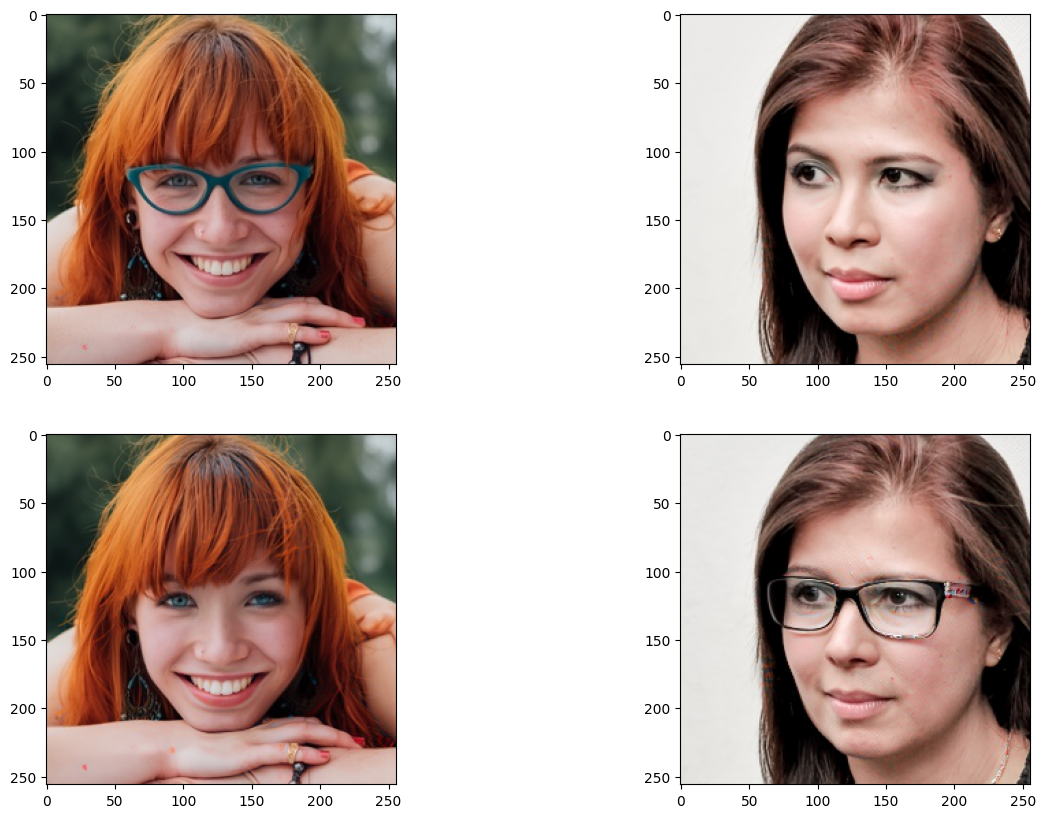

In [17]:
import matplotlib.pyplot as plt
# torch.manual_seed(1)
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
ax[0,0].imshow(recon_glass[0].permute(1, 2, 0).cpu())
ax[0,1].imshow(recon_bg[0].permute(1, 2, 0).cpu())
ax[1,0].imshow(swap_glass[0].permute(1, 2, 0).cpu())
ax[1,1].imshow(swap_bg[0].permute(1, 2, 0).cpu())

# plt.savefig('imgs_manipulated/compare.png')

In [18]:
# the learned glass must not affect the faces

print('c_glass_norm', c_glass_norm[:, 20:40])
print('\n')
print('c_bg_norm', c_bg_norm[:, 20:40])
print('\n')
print('s_glass_norm', s_norm[:, 20:40])
print('\n')
# print('s_bg_norm', s_bg_norm[:, 20:40])
# print('\n')



c_glass_norm tensor([[-0.3370, -1.5748,  0.1559, -0.5135, -2.1204,  0.3720,  1.7490,  0.6696,
         -1.1930, -1.2267,  0.3221, -0.0650, -1.1907, -1.4485, -0.5178, -0.2307,
          0.7149, -0.6149,  0.6284,  0.9829]], device='cuda:0')


c_bg_norm tensor([[-0.0964, -0.3305,  0.8171,  0.8361,  0.2980,  0.7398, -0.6343, -0.0456,
          0.1746,  0.5170, -0.1836, -0.0910,  1.7659, -0.6012, -1.4575, -0.3324,
          0.5842,  0.1217,  1.0934, -1.0959]], device='cuda:0')


s_glass_norm tensor([[-0.8652,  0.1201, -0.5639, -0.0209,  0.0174,  0.1406,  0.0970, -0.4709,
          0.0922, -0.2018,  0.5187, -0.9674, -0.4649,  0.0938, -0.0675,  1.1233,
         -0.4148, -0.1646, -0.4488,  0.2152]], device='cuda:0',
       grad_fn=<SliceBackward0>)




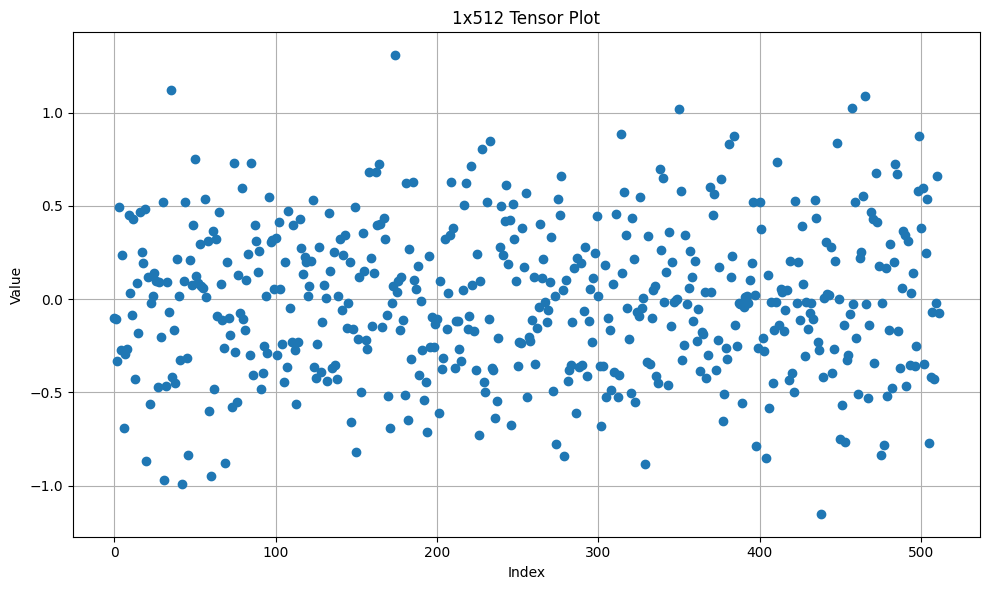

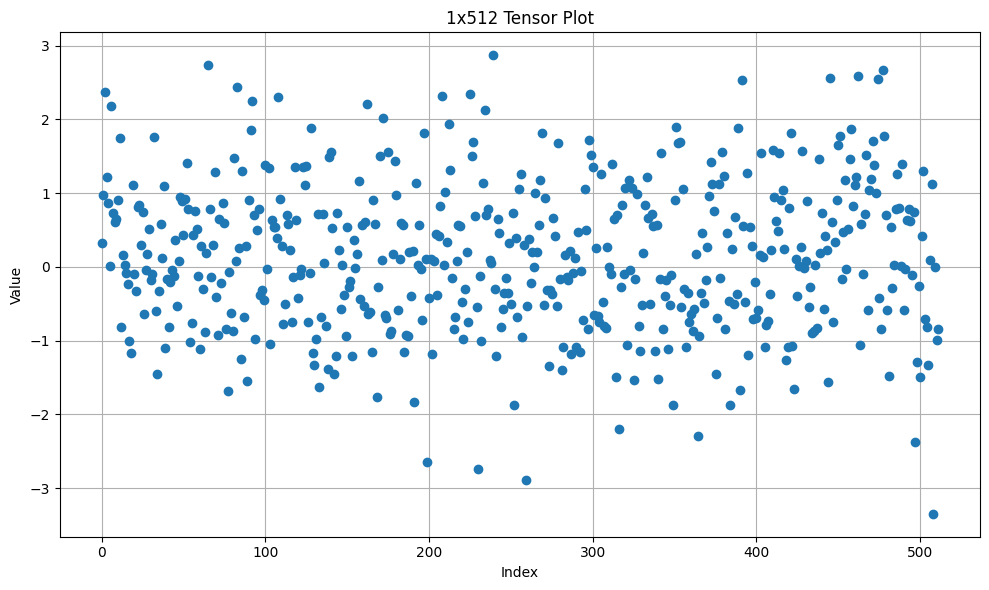

In [19]:
import torch

# Create a 1x512 tensor
s_bg_norm = 0.4* math.sqrt(512) * F.normalize(cls_model.classifier.weight[cls_id][None, :], dim=1)
tensor = s_bg_norm.cpu().detach().numpy()  # Random values for demonstration

# Convert tensor to numpy for plotting
vector = tensor.flatten()

# Create x-axis indices
x_indices = np.arange(vector.shape[0])

# Plot the tensor
plt.figure(figsize=(10, 6))
plt.plot(x_indices, vector, marker='o', linestyle='', linewidth=1)
plt.title("1x512 Tensor Plot")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

import torch

# Create a 1x512 tensor
tensor = c_bg_norm.cpu().detach().numpy()  # Random values for demonstration

# Convert tensor to numpy for plotting
vector = tensor.flatten()

# Create x-axis indices
x_indices = np.arange(vector.shape[0])

# Plot the tensor
plt.figure(figsize=(10, 6))
plt.plot(x_indices, vector, marker='o', linestyle='', linewidth=1)
plt.title("1x512 Tensor Plot")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


In [20]:
s_bg_norm.shape

torch.Size([1, 512])

In [21]:
# s_bg_norm = 0.1* torch.randn(s_bg_norm.shape)

c_glass_norm = cls_model.normalize(cond_bg)
s_glass_norm1 = 0.3* math.sqrt(512) * F.normalize(cls_model.classifier.weight[cls_id][None, :], dim=1)
s_glass_norm2 = 0.4* math.sqrt(512) * F.normalize(cls_model.classifier.weight[cls_id][None, :], dim=1)
s_glass_norm3 = 0.5* math.sqrt(512) * F.normalize(cls_model.classifier.weight[cls_id][None, :], dim=1)
s_glass_norm4 = 0.6* math.sqrt(512) * F.normalize(cls_model.classifier.weight[cls_id][None, :], dim=1)
s_glass_norm5 = 0.7* math.sqrt(512) * F.normalize(cls_model.classifier.weight[cls_id][None, :], dim=1)
s_glass_norm6 = 0.8* math.sqrt(512) * F.normalize(cls_model.classifier.weight[cls_id][None, :], dim=1)


swap_to_glass1 = cls_model.denormalize(cls_model.normalize(cond_bg) + s_glass_norm1.to(device))
swap_to_glass2 = cls_model.denormalize(cls_model.normalize(cond_bg) + s_glass_norm2.to(device))
swap_to_glass3 = cls_model.denormalize(cls_model.normalize(cond_bg) + s_glass_norm3.to(device))
swap_to_glass4 = cls_model.denormalize(cls_model.normalize(cond_bg) + s_glass_norm4.to(device))
swap_to_glass5 = cls_model.denormalize(cls_model.normalize(cond_bg) + s_glass_norm5.to(device))
swap_to_glass6 = cls_model.denormalize(cls_model.normalize(cond_bg) + s_glass_norm6.to(device))

recon_1 = model.render(xT_bg, swap_to_glass1, T=100)
recon_2 = model.render(xT_bg, swap_to_glass2, T=100)
recon_3 = model.render(xT_bg, swap_to_glass3, T=100)
recon_4 = model.render(xT_bg, swap_to_glass4, T=100)
recon_5 = model.render(xT_bg, swap_to_glass5, T=100)
recon_6 = model.render(xT_bg, swap_to_glass6, T=100)



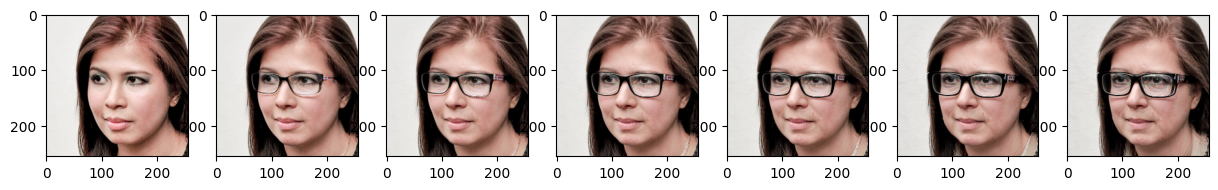

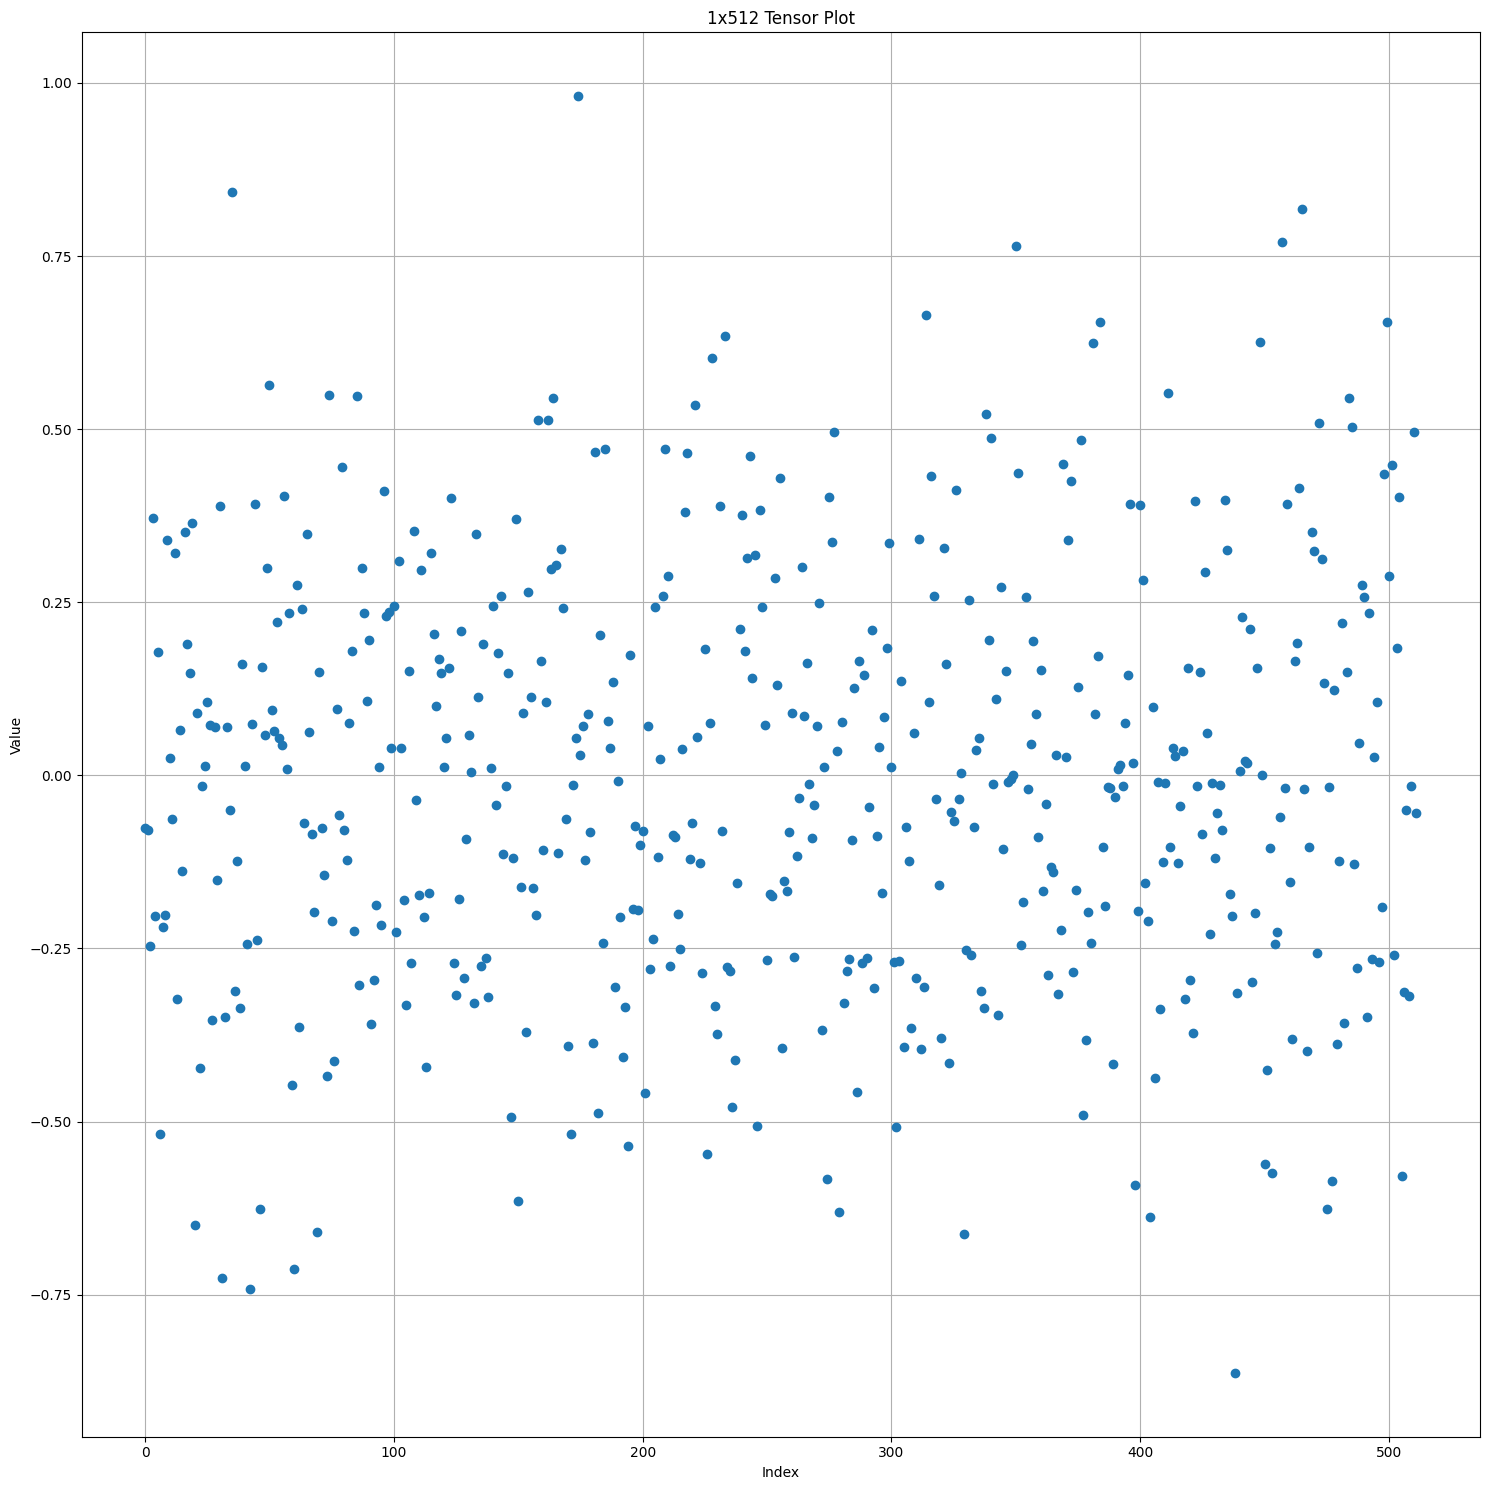

In [22]:
fig, ax = plt.subplots(1, 7, figsize=(15, 8))

ax[0].imshow(ori_bg[0].permute(1, 2, 0).cpu())
ax[1].imshow(recon_1[0].permute(1, 2, 0).cpu())
ax[2].imshow(recon_2[0].permute(1, 2, 0).cpu())
ax[3].imshow(recon_3[0].permute(1, 2, 0).cpu())
ax[4].imshow(recon_4[0].permute(1, 2, 0).cpu())
ax[5].imshow(recon_5[0].permute(1, 2, 0).cpu())
ax[6].imshow(recon_6[0].permute(1, 2, 0).cpu())

# # Create a 1x512 tensor
# s_bg_norm = 0.4* math.sqrt(512) * F.normalize(cls_model.classifier.weight[cls_id][None, :], dim=1)
tensor = s_glass_norm1.cpu().detach()  # Random values for demonstration

# Convert tensor to numpy for plotting
vector = tensor.flatten()

# Create x-axis indices
x_indices = np.arange(vector.shape[0])

# Plot the tensor
plt.figure(figsize=(15, 15))
plt.plot(x_indices, vector, marker='o', linestyle='', linewidth=1)
plt.title("1x512 Tensor Plot")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()